Import Required Libraries

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import os

Download Dataset

In [2]:
path = kagglehub.dataset_download(
    "vijayaadithyanvg/car-price-predictionused-cars"
)

print("Dataset Path:", path)

100%|██████████| 3.76k/3.76k [00:00<00:00, 7.14MB/s]

Extracting files...
Dataset Path: /root/.cache/kagglehub/datasets/vijayaadithyanvg/car-price-predictionused-cars/versions/1


Check Dataset Files

In [3]:
print(os.listdir(path))

['car data.csv']


Load Dataset

In [4]:
file_name = os.listdir(path)[0]

df = pd.read_csv(os.path.join(path, file_name))

print(df.head())

  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  


Check Dataset Information

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None


Check Missing Values

In [6]:
print(df.isnull().sum())

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


Statistical Summary

In [7]:
print(df.describe())

              Year  Selling_Price  Present_Price     Driven_kms       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.642584   38886.883882    0.247915
min    2003.000000       0.100000       0.320000     500.000000    0.000000
25%    2012.000000       0.900000       1.200000   15000.000000    0.000000
50%    2014.000000       3.600000       6.400000   32000.000000    0.000000
75%    2016.000000       6.000000       9.900000   48767.000000    0.000000
max    2018.000000      35.000000      92.600000  500000.000000    3.000000


Encode Text Columns

In [8]:
categorical_columns = df.select_dtypes(
    include=["object"]
).columns

print(categorical_columns)

Index(['Car_Name', 'Fuel_Type', 'Selling_type', 'Transmission'], dtype='object')


In [9]:
encoder = LabelEncoder()

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

In [11]:
X = df.drop("Selling_Price", axis=1)

y = df["Selling_Price"]

Split Dataset

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Train Model

In [13]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

Predict Prices

In [14]:
predictions = model.predict(X_test)

print(predictions)

[ 0.4433 10.32    5.01    0.2094  7.8531  6.712   1.1306  0.6118  0.464
  6.641   8.5415  1.1076  7.7683  0.4519  5.2805  2.5645  1.1441 14.6331
  0.4643  1.562   0.3259  7.7878  4.724   2.7225  0.5039  3.4735  5.351
  3.2125  1.1763  1.1608  0.4038  8.1788  0.4639  2.487   8.0283  4.0315
  6.4497  6.1305  2.47    6.6603  4.9542  3.7173  4.7115  0.5678  6.2725
  0.7103  8.006   7.059   2.9005  3.5895  4.951   1.529  22.882  20.6695
  6.5015  9.9883  5.141   8.7332  2.9794  6.599   0.2425]


Evaluate Model

In [15]:
mae = mean_absolute_error(
    y_test,
    predictions
)

print("Mean Absolute Error:", mae)
r2 = r2_score(
    y_test,
    predictions
)

print("R2 Score:", r2)

Mean Absolute Error: 0.589304918032787
R2 Score: 0.9660248711535068


Feature Importance Graph

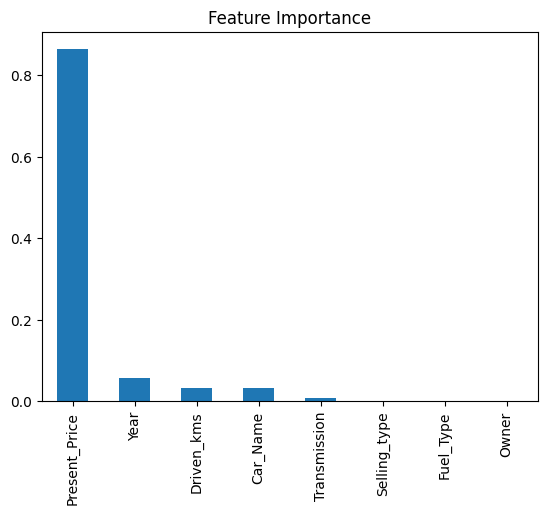

In [16]:
importance = model.feature_importances_

pd.Series(
    importance,
    index=X.columns
).sort_values(
    ascending=False
).plot(kind="bar")

plt.title("Feature Importance")
plt.show()

Actual vs Predicted Graph

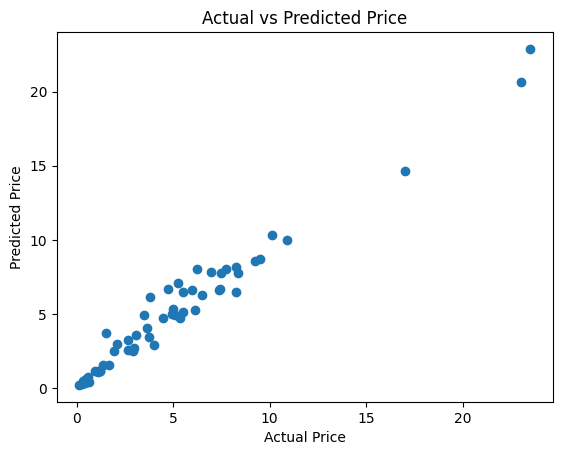

In [17]:
plt.scatter(
    y_test,
    predictions
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")

plt.show()

Predict Single Car Price

In [18]:
sample = X.iloc[0:1]

price = model.predict(sample)

print("Predicted Price:", price)

Predicted Price: [3.8885]
